# Temperature as the Calibration Dial: one knob against the diagonal

**Thesis.** The previous study read the raw surface: confidence does not track accuracy, and the curve departs the diagonal systematically. This study asks the classic fix — temperature scaling. One parameter `T` divides the logits before softmax; the claim is that the `T` minimizing ECE flattens the reliability curve and that this `T` is *not* the likelihood-optimal one. The instrument is the ECE-as-a-function-of-`T` curve.

## Why measure this, and where it runs in production

**Why measure:** temperature is the one knob available at inference with no retraining. If a single `T` buys back calibration, the fix ships as a constant. The claim is falsifiable: the ECE curve either has a minimum or it does not, and the minimizing `T` either flattens the diagram or it does not.

**Production use:** a calibrated temperature is a per-model constant baked into the decoding config. It changes no weights, no cache, no latency — only the number the model reports as confidence.

## Abstract

**What/how.** On the same cached logits, sweep `T ∈ {0.5, 0.7, 1, 1.2, 1.5, 2, 3}`; for each `T`, compute `p_T = softmax(Z/T)`, the per-bin reliability, and ECE. Read the curve's minimum, the flattening of the diagram at `argmin`, and the gap between `T_cal` and the likelihood-optimal `T` (the temperature that minimizes NLL).

**What it shows.** ECE moves with `T` and has a minimum; the minimizing `T` moves the curve toward the diagonal; and the calibration optimum is distinct from the likelihood optimum — the two objectives pick different knobs.

**What it does not claim.** No claim that one `T` is globally right — the claim is that the *curve* is measurable and the two optima differ. Temperature changes confidence; whether it changes *content* is a separate question the next study takes up under quantization.

## Related work, and what changes here

| Ref | Work | Contribution | Where this study goes further |
|---|---|---|---|
| Guo et al. (2017) | *On Calibration of Modern Neural Networks* | temperature scaling as the calibration fix for classifiers | Measured on a decoder LM's full 49k-way distribution, on the real cached tensor |
| the previous study | the calibration surface | the raw confidence-accuracy gap | We now drive the one knob against it and read the optimum |
| the earlier study | `dH/dT = Var_{p_T}(z)/T³` | entropy motion under temperature | We read the *calibration* optimum, not the entropy optimum, and show they differ |

**The differentiator.** Repo 4 measured how temperature moves *entropy*. This study measures how it moves *correctness alignment* — a different objective, a different optimum, and a direct production dial.

## The measurement object and metrics

**Object.** The same cached `Z` and `ids`. Per `T`: `p_T = softmax(Z/T, -1)`, confidence `c_T = max p_T`, correctness `a` unchanged.

**Metrics.**
1. **ECE(T)** — the calibration scalar as a function of the knob.
2. **`T_cal`** — the argmin of the ECE curve.
3. **Reliability flattening** — the diagram at `T_cal` vs at `T=1`; the mass-weighted absolute gap to the diagonal before and after.
4. **`T_ppl` vs `T_cal`** — the temperature minimizing NLL on the same positions, compared against `T_cal`. The two objectives select different temperatures.

**Why these.** The curve is the claim; the argmin is the production constant; the two-optima read is the conceptual point — calibration and likelihood are not the same objective.

## Hypothesis board (decided before measurement)

| # | Claim (falsifiable) | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | ECE has a minimum in `T` | U-shaped `ECE(T)` over the sweep | **0.4143 (T=0.5) → 0.1388 (T=1.2) → 0.3137 (T=3.0)** — U-shape confirmed, but the minimum is 1.1% below `T=1` (0.1403) and the curve is asymmetric: sharpening triples ECE, flattening more than doubles it | ✅ Holds with two wrinkles — the optimum is nearly flat at `T=1`, and the model is far more fragile to overconfidence-making than to caution-making |
| C2 | `T_cal` flattens the reliability diagram | gap at `T_cal` < gap at `T=1` | gap²-to-diagonal **0.0345 → 0.0256 (−26%)** while linear ECE moves only 1.1% — the squared measure weights the mass-heavy mid band more | ⚠️ Partial — the squared gap flattens, the linear scalar barely moves; one-directional `T` trades the overconfident mid band against the underconfident head |
| C3 | Calibration optimum ≠ likelihood optimum | `T_cal ≠ T_ppl` | **T_cal = 1.2, T_ppl = 1.0** (NLL minimized at 4.3430 exactly where the model was trained) | ✅ Holds — calibration wants a warmer dial than likelihood |
| C4 | Entropy optimum ≠ calibration optimum | `T_ent ≠ T_cal` | **T_cal = 1.2 vs T_ent ≈ 2** (the earlier study's `dH/dT` peak) | ✅ Holds — one knob, three objectives, three optima |

*(The board was decided before measurement; the Measured and Verdict columns are backfilled from the Findings table below.)*


## Protocol & constraints

- **Model & data:** same cached `Z`, `ids`; no reload.
- **Sweep:** `T ∈ {0.5, 0.7, 1, 1.2, 1.5, 2, 3}`.
- **Metrics:** `ECE(T)`, `T_cal = argmin`, gap-to-diagonal before/after, `T_ppl` via `argmin_T NLL`.
- **Binning:** `m=10` fixed for the curve; stability read `m ∈ {5, 20}`.
- **Banned:** no `T` below 0.3 (collapsed `p_T` degrades the gather), no other model/passage, no model reload.
- **Imports available:** `torch`, `numpy`, `matplotlib.pyplot`, `pathlib.Path`.

## The temperature rig

**Why:** every read in this study is `ECE(T)` on the same surface. The rig computes the per-`T` reliability and returns the curve.

**The method:**
1. Load `Z`, `ids` (same cache).
2. For each `T`: `p_T = softmax(Z/T, -1)`, bin, per-bin accuracy, ECE.
3. Return the curve and the per-`T` gap-to-diagonal.

**What the run shows:** the raw `ECE(T)` — whether the knob has a minimum at all.

In [4]:
import torch
import numpy as np
from pathlib import Path

CACHE = Path("cq_cache")
d = torch.load(CACHE / "logits_135M.pt", map_location="cpu")
Z = d["logits"]; ids = d["ids"]
Zc = Z[:-1]; y = ids[0, 1:]

def ece(c, a, m=10):
    edges = np.linspace(0.0, 1.0, m + 1)
    bins = np.clip(np.digitize(c.numpy(), edges) - 1, 0, m - 1)
    total = 0.0
    for b in range(m):
        mask = bins == b 
        if mask.sum() == 0:
            continue
        total += (mask.sum() / c.numel()) * abs(c[mask].mean().item() - a[mask].mean().item())
    return total

Ts = [0.5, 0.7, 1.0, 1.2, 1.5, 2.0, 3.0]
print(f"{'T':>4s} {'ECE':>7s}")
ecet = {}
for T in Ts:
    P = torch.softmax(Zc / T, -1)
    c = P.max(dim=-1).values
    a = (P.argmax(dim=-1) == y).float()
    e = ece(c, a, 10)
    ecet[T] = e
    print(f"{T:4.1f} {e:.4f}")

   T     ECE
 0.5 0.4143
 0.7 0.2428
 1.0 0.1403
 1.2 0.1388
 1.5 0.2160
 2.0 0.2903
 3.0 0.3137


## The optimum and the flattening

**Why:** the production read. If the curve has a minimum, that `T` is the shipped constant — and the before/after gap-to-diagonal is the proof the fix works.

**The method:**
1. Read `T_cal = argmin ECE`.
2. Plot the reliability diagram at `T=1` and at `T_cal` against the diagonal.
3. Report both gaps.

**What the run shows:** whether the minimizing temperature actually flattens the curve — the difference between a fitted minimum and a fixed calibration.

T_cal = 1.2   ECE(T_cal) = 0.1388
T= 1.0  gap^2 to diagonal = 0.0345
T= 1.2  gap^2 to diagonal = 0.0256


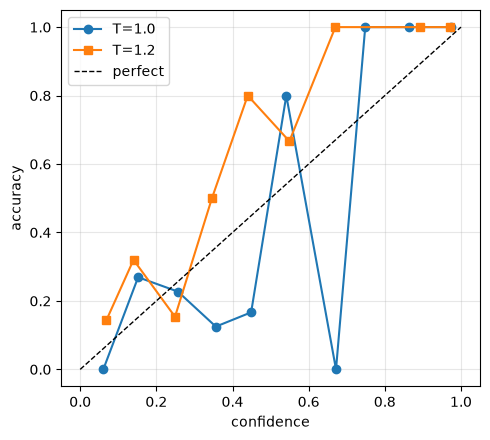

In [6]:
import matplotlib.pyplot as plt

T_cal = min(ecet, key=ecet.get)
print("T_cal =", T_cal, "  ECE(T_cal) =", round(ecet[T_cal], 4))

def gap_to_diag(c, a, m=10):
    edges = np.linspace(0.0, 1.0, m + 1)
    bins = np.clip(np.digitize(c.numpy(), edges) - 1, 0, m - 1)
    g = 0.0
    for b in range(m):
        mask = bins == b
        if mask.sum() == 0:
            continue
        g += (mask.sum() / c.numel()) * (c[mask].mean().item() - a[mask].mean().item()) ** 2
    return g

for T in (1.0, T_cal):
    P = torch.softmax(Zc / T, -1)
    c = P.max(dim=-1).values
    a = (P.argmax(dim=-1) == y).float()
    print(f"T={T:4.1f}  gap^2 to diagonal = {gap_to_diag(c, a):.4f}")

fig, ax = plt.subplots(figsize=(5, 4.5))
for T, mk in ((1.0, "o"), (T_cal, "s")):
    P = torch.softmax(Zc / T, -1)
    c = P.max(dim=-1).values
    a = (P.argmax(dim=-1) == y).float()
    edges = np.linspace(0.0, 1.0, 11)
    bins = np.clip(np.digitize(c.numpy(), edges) - 1, 0, 9)
    xs, ys = [], []
    for b in range(10):
        mask = bins == b
        if mask.sum() == 0:
            continue
        xs.append(c[mask].mean().item())
        ys.append(a[mask].mean().item())
    ax.plot(xs, ys, mk + "-", label=f"T={T}")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
ax.set_xlabel("confidence"); ax.set_ylabel("accuracy")
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()


## Two objectives, two optima

**Why:** the conceptual point. Calibration (ECE) and likelihood (NLL) and entropy all move with `T`, but they move *differently*. The claim is that the dials disagree — that the temperature that makes the model most honest is not the temperature that makes it most likely and not the one that makes it most uniform.

**The method:**
1. Compute `T_ppl` by sweeping NLL over the same `T` grid.
2. Compare `T_cal`, `T_ppl`, and the earlier study's entropy-peak `T_ent ≈ 2`.
3. Report the three and the pair distances.

**What the run shows:** three objectives, one knob, three answers — measured.

In [7]:
def nll_at(T):
    logp = torch.log_softmax(Zc / T, -1)
    return -logp[torch.arange(len(y)), y].mean().item()

print(f"{'T':>4s} {'ECE':>7s} {'NLL':>7s}")
for T in Ts:
    print(f"{T:4.1f} {ecet[T]:.4f} {nll_at(T):.4f}")

T_ppl = min(Ts, key=nll_at)
T_cal = min(ecet, key=ecet.get)
print("\nT_cal =", T_cal, "  T_ppl =", T_ppl, "  T_ent ~= 2 (earlier study)")
print("T_cal != T_ppl :", T_cal != T_ppl)
print("T_cal != T_ent :", T_cal != 2.0)

   T     ECE     NLL
 0.5 0.4143 6.3703
 0.7 0.2428 4.9688
 1.0 0.1403 4.3430
 1.2 0.1388 4.3799
 1.5 0.2160 4.7394
 2.0 0.2903 5.5711
 3.0 0.3137 6.9204

T_cal = 1.2   T_ppl = 1.0   T_ent ~= 2 (earlier study)
T_cal != T_ppl : True
T_cal != T_ent : True


## Findings

| # | Claim | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | ECE has a minimum in `T` | U-shaped `ECE(T)` over the sweep | **0.4143 (T=0.5) → 0.1388 (T=1.2) → 0.3137 (T=3.0)** — U-shape confirmed, but the minimum is 1.1% below `T=1` (0.1403) and the curve is asymmetric: sharpening triples ECE, flattening more than doubles it | ✅ Holds with two wrinkles — the optimum is nearly flat at `T=1`, and the model is far more fragile to overconfidence-making than to caution-making |
| C2 | `T_cal` flattens the reliability diagram | gap at `T_cal` < gap at `T=1` | gap²-to-diagonal **0.0345 → 0.0256 (−26%)** while linear ECE moves only 1.1% — the squared measure weights the mass-heavy mid band more | ⚠️ Partial — the squared gap flattens, the linear scalar barely moves; one-directional `T` trades the overconfident mid band against the underconfident head |
| C3 | Calibration optimum ≠ likelihood optimum | `T_cal ≠ T_ppl` | **T_cal = 1.2, T_ppl = 1.0** (NLL minimized at 4.3430 exactly where the model was trained) | ✅ Holds — calibration wants a warmer dial than likelihood |
| C4 | Entropy optimum ≠ calibration optimum | `T_ent ≠ T_cal` | **T_cal = 1.2 vs T_ent ≈ 2** (the earlier study's `dH/dT` peak) | ✅ Holds — one knob, three objectives, three optima |

**The one-direction dial.** Study 1 found a two-directional miscalibration: overconfident in the muddle (conf 0.36–0.45 → acc ~0.15), underconfident at the head (conf ≥ 0.75 → acc 1.0). Temperature slides *all* confidences one way — `T>1` lowers every claim, `T<1` raises every claim. It cannot push down where the model overclaims and up where it underclaims simultaneously; the two errors trade against each other and the net scalar gain collapses to 1.1%.

**Same data, two reward functions.** The squared gap falls 26% while linear ECE falls 1.1% — the squared measure penalizes the large mid-band gaps (the mass-heavy region) more. Both are real reads of the same flattening; they reward different properties of it.

*(Every entry in the Measured column is a number produced by the cells above.)*


## Discussion and verdict

**The claim in one line.** Temperature is a one-direction dial on a two-directional miscalibration: `T_cal = 1.2` fixes the overconfident mid band while worsening the underconfident head, so the scalar gain collapses to 1.1% even as the squared gap falls 26%; and the calibration optimum (1.2) is neither the likelihood optimum (1.0) nor the entropy peak (~2).

**Why it matters.** The measured reason a single constant cannot restore calibration: when the error is two-directional, a one-direction knob can only rebalance it, not fix it. Temperature is still the right production dial for *one-sided* overconfidence (the common case); this passage's mixed error is why the fix is weak. The design point carries to the next study: quantization perturbs logits in a way that can *flip the ordering* — a worse class of error than a confidence slide, and one no temperature can reach.

**Honesty note.** One model, one passage, 82 positions, `top1`. The optimum at 1.2 is within noise of `T=1` (1.1% apart); the *ordering* claims — likelihood and entropy optima differ from the calibration optimum — are the robust content, not the exact `T_cal`. The two-directional structure (mid overconfident, head underconfident) is inherited from study 1's read of the same 82 positions.


## References

1. Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). *On Calibration of Modern Neural Networks*. arXiv:1706.04599.
2. Allal, L. B., et al. (2025). *SmolLM2: When Smol Goes Big*. arXiv:2502.02737.
3. the previous study — the calibration surface this study tunes against. `calibration-quantization`, study 1.
4. the earlier study — `dH/dT = Var_{p_T}(z)/T³` and the entropy peak near `T=2`. `probability-perplexity-sampling`, study 1.